In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [51]:
df = pd.read_csv ("C:\\Users\\Divya Devikar\\Downloads\\07. Advertising.csv")

In [52]:
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [53]:
df.shape

(200, 5)

In [55]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


In [78]:
print(f"Dataset has {X.shape[0]} samples and {X.shape[1]} features")
print(f"Features: {list(X.columns)}")
print(f"Target Variable: {y.name}")

Dataset has 200 samples and 3 features
Features: ['TV', 'Radio', 'Newspaper']
Target Variable: Sales


In [79]:
y.value_counts()

Sales
9.7     5
12.9    4
15.9    4
11.7    4
10.6    3
       ..
17.6    1
6.7     1
9.9     1
5.9     1
25.5    1
Name: count, Length: 121, dtype: int64

In [56]:
print(df.isnull().sum())

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [60]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [61]:
df = df.drop("Unnamed: 0", axis=1)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [62]:
X = df[['TV','Radio','Newspaper']]
y = df['Sales']

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42
)

In [140]:
median_sales = y.median()

In [141]:
y_test_class = (y_test > median_sales).astype(int)

In [142]:
y_pred_class = (y_pred > median_sales).astype(int)

In [143]:
#Sales > median → High Sales (1)
#Sales ≤ median → Low Sales (0)

In [144]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [145]:
knn = KNeighborsRegressor(n_neighbors=5)

In [146]:
knn.fit(X_train, y_train)

KNeighborsRegressor()

In [147]:
y_pred = knn.predict(X_test)

In [148]:
print(y_pred)

[18.08 21.62 19.94  9.78 22.3  13.16 22.34  8.5  12.42 14.86 10.04  7.74
 13.6   7.92 10.42 12.38  8.52 16.26 11.26 18.56 22.48 12.9   7.74 22.48
  9.9   7.92 21.4  12.92 10.46  7.42 12.28 10.88 21.7  10.48 14.62 20.24
  7.74 20.2  11.    6.94]


In [149]:
knn.score(X_test,y_test)

0.9300640472854901

In [150]:
k_range = range(1,16)
k_scores = []

for k in k_range:
    
    knn = KNeighborsRegressor(n_neighbors=k)
    
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='r2')
    
    k_scores.append(scores.mean())

In [151]:
print("K values:", list(k_range))

print("Scores:", k_scores)

K values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Scores: [np.float64(0.8978284309260948), np.float64(0.9035014879177939), np.float64(0.9077507299102459), np.float64(0.9100268722743113), np.float64(0.9040350696327097), np.float64(0.8950084137929938), np.float64(0.8926641637940452), np.float64(0.8841594858114217), np.float64(0.8827954692602106), np.float64(0.8732280152770093), np.float64(0.8653434782412311), np.float64(0.8557366977616526), np.float64(0.8559581555830297), np.float64(0.8451476833478097), np.float64(0.8411090351829179)]


In [152]:
best_k = k_range[np.argmax(k_scores)]
best_score = max(k_scores)

print("Best K value:", best_k)
print("Best Score:", best_score)

Best K value: 4
Best Score: 0.9100268722743113


In [153]:
accuracy = accuracy_score(y_test_class, y_pred_class)

print("Accuracy:", accuracy)

Accuracy: 0.95


In [154]:
precision = precision_score(y_test_class, y_pred_class)

print("Precision:", precision)

Precision: 0.8888888888888888


In [155]:
recall = recall_score(y_test_class, y_pred_class)

print("Recall:", recall)

Recall: 1.0


In [156]:
print(classification_report(y_test_class, y_pred_class))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        24
           1       0.89      1.00      0.94        16

    accuracy                           0.95        40
   macro avg       0.94      0.96      0.95        40
weighted avg       0.96      0.95      0.95        40



In [157]:
joblib.dump(knn, "knn_sales_model.pkl")

['knn_sales_model.pkl']

In [158]:
model = joblib.load("knn_sales_model.pkl")

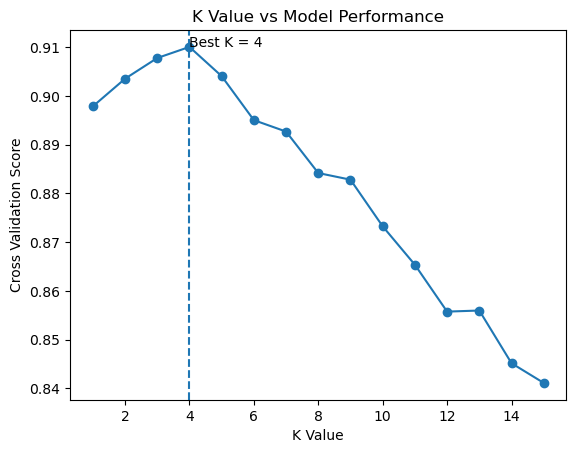

In [159]:
plt.plot(k_range, k_scores, marker='o')

plt.xlabel("K Value")
plt.ylabel("Cross Validation Score")
plt.title("K Value vs Model Performance")
plt.axvline(best_k, linestyle='--')
plt.text(best_k, best_score, f'Best K = {best_k}')

plt.show()
